In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv("german.data", sep=r"\s+", header=None)

In [3]:
df.columns = [
    "status_checking_account",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_since",
    "installment_rate",
    "personal_status_sex",
    "other_debtors_guarantors",
    "present_residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "number_existing_credits",
    "job",
    "number_people_liable",
    "telephone",
    "foreign_worker",
    "target"
]

In [4]:
df.shape

(1000, 21)

In [5]:
# First 5 rows
print(df.head())

# Data types
print(df.dtypes)

# Missing values
print(df.isnull().sum())

# Target distribution before recoding
print(df["target"].value_counts())

  status_checking_account  duration_months credit_history purpose  \
0                     A11                6            A34     A43   
1                     A12               48            A32     A43   
2                     A14               12            A34     A46   
3                     A11               42            A32     A42   
4                     A11               24            A33     A40   

   credit_amount savings_account employment_since  installment_rate  \
0           1169             A65              A75                 4   
1           5951             A61              A73                 2   
2           2096             A61              A74                 2   
3           7882             A61              A74                 2   
4           4870             A61              A73                 3   

  personal_status_sex other_debtors_guarantors  ...  property age  \
0                 A93                     A101  ...      A121  67   
1                 A9

In [6]:
df["target"] = df["target"].replace({1: 0, 2: 1})
print(df["target"].value_counts())

target
0    700
1    300
Name: count, dtype: int64


In [8]:
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("Numerical columns:")
print(numerical_cols)

Categorical columns:
['status_checking_account', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors_guarantors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
Numerical columns:
['duration_months', 'credit_amount', 'installment_rate', 'present_residence_since', 'age', 'number_existing_credits', 'number_people_liable']


In [13]:
# One-hot encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [14]:
encoded_cat_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(encoded_cat_names)

# Convert processed arrays to DataFrames for easier viewing
X_train_processed_df = pd.DataFrame(
    X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed,
    columns=all_feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed,
    columns=all_feature_names,
    index=X_test.index
)

print("\nFirst 5 rows of processed training data:")
print(X_train_processed_df.head())


First 5 rows of processed training data:
     duration_months  credit_amount  installment_rate  \
828         1.289592       1.925766          0.052281   
997        -0.742595      -0.892853          0.942164   
148         1.289592       0.816433          0.052281   
735         1.289592       0.299568          0.052281   
130         2.305686       1.982655         -1.727486   

     present_residence_since       age  number_existing_credits  \
828                 1.053413  1.057784                -0.718745   
997                 1.053413  0.242449                -0.718745   
148                -0.747293 -0.663479                 1.045047   
735                -0.747293 -0.572886                -0.718745   
130                -0.747293 -1.025850                -0.718745   

     number_people_liable  status_checking_account_A12  \
828             -0.436436                          0.0   
997             -0.436436                          0.0   
148             -0.436436             

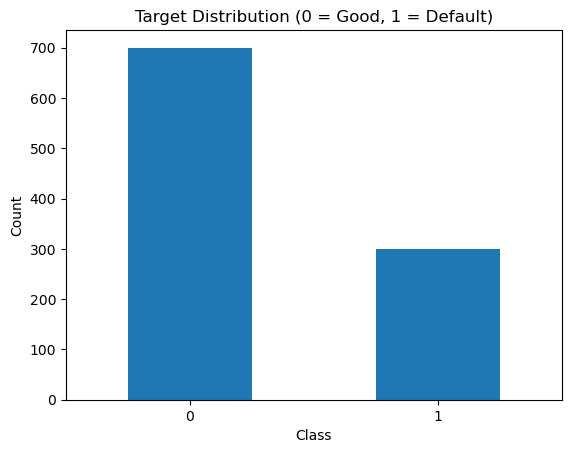

In [17]:
plt.figure()
y.value_counts().sort_index().plot(kind='bar')
plt.title("Target Distribution (0 = Good, 1 = Default)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

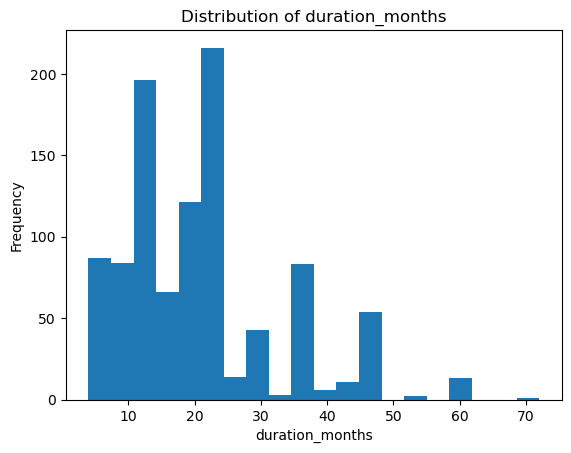

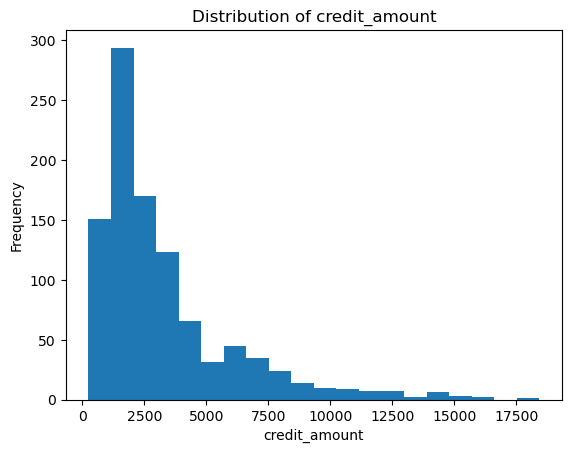

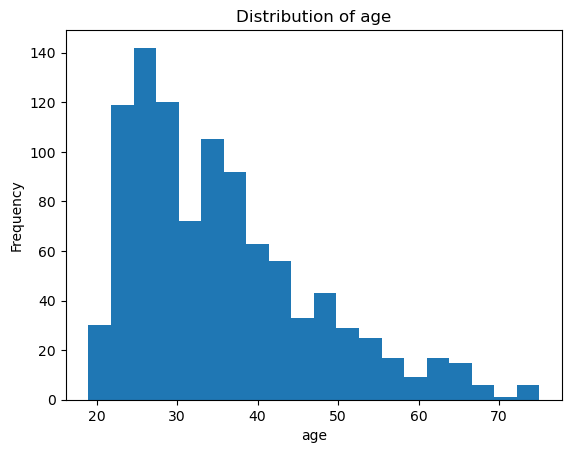

In [18]:
numerical_cols = ["duration_months", "credit_amount", "age"]

for col in numerical_cols:
    plt.figure()
    plt.hist(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

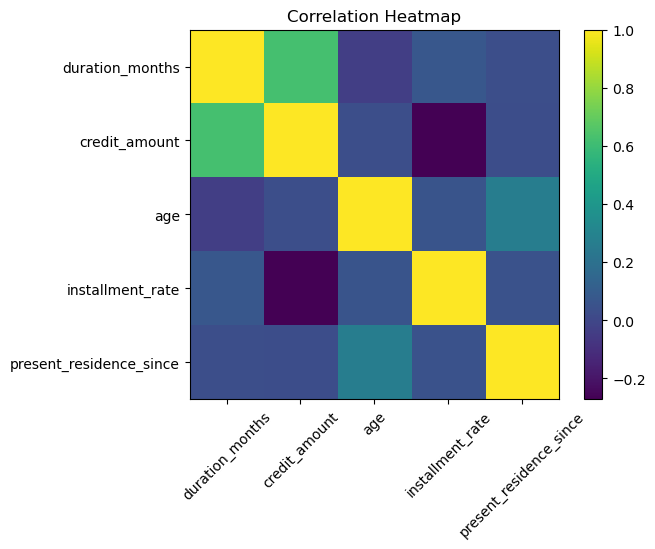

In [19]:
corr = df[numerical_cols + ["installment_rate", "present_residence_since"]].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

<Figure size 640x480 with 0 Axes>

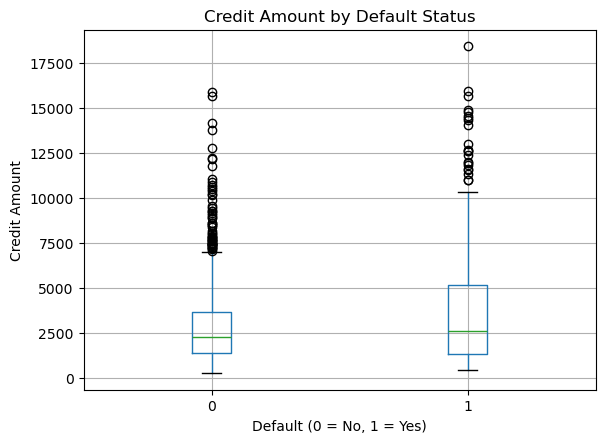

In [20]:
plt.figure()
df.boxplot(column="credit_amount", by="target")
plt.title("Credit Amount by Default Status")
plt.suptitle("")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Credit Amount")
plt.show()

In [22]:
model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
model_l1.fit(X_train_processed, y_train)

coef = model_l1.coef_[0]

selected_features = np.array(all_feature_names)[coef != 0]

print("Selected Features:")
print(selected_features)

print("\nNumber of selected features:", len(selected_features))

Selected Features:
['duration_months' 'credit_amount' 'installment_rate'
 'present_residence_since' 'age' 'number_existing_credits'
 'number_people_liable' 'status_checking_account_A12'
 'status_checking_account_A13' 'status_checking_account_A14'
 'credit_history_A31' 'credit_history_A32' 'credit_history_A33'
 'credit_history_A34' 'purpose_A41' 'purpose_A410' 'purpose_A42'
 'purpose_A43' 'purpose_A46' 'purpose_A49' 'savings_account_A62'
 'savings_account_A63' 'savings_account_A64' 'savings_account_A65'
 'employment_since_A72' 'employment_since_A73' 'employment_since_A74'
 'personal_status_sex_A93' 'personal_status_sex_A94'
 'other_debtors_guarantors_A102' 'other_debtors_guarantors_A103'
 'property_A122' 'property_A123' 'property_A124'
 'other_installment_plans_A142' 'other_installment_plans_A143'
 'housing_A152' 'housing_A153' 'job_A173' 'telephone_A192'
 'foreign_worker_A202']

Number of selected features: 41
